# Figures 1–3 and Appendix Figures A1–A2

Every number below is read from an aggregate result artifact in `../artifacts/` — the same files the paper's tables and figures were generated from.
No licensed microdata is used or required (see `../DATA_ACCESS.md`). Outputs are stored in this notebook, so everything renders on GitHub without running anything.
The code cells are cut verbatim from `../code/build/p001_09_exhibits.py`; the last cell checks the result against `../paper_exhibits/`, the exhibits attached to the manuscript.


## Setup — `p001_09_exhibits.py` executed up to its figure section (the figure cells below are its verbatim continuation)


In [ ]:
import os
__file__ = os.path.abspath("../code/build/p001_09_exhibits.py")
os.environ["P001_ARTIFACTS"] = os.path.abspath("../artifacts"); os.environ["P001_TABLES"] = os.path.abspath("../figures/tables/components"); os.environ["P001_TABLES_FINAL"] = os.path.abspath("../figures/tables"); os.environ["P001_FIGURES"] = os.path.abspath("../figures")
# The figures reuse quantities computed while the tables are built, so the generator is executed here up to its figure section (tables are regenerated silently into ../figures/tables).
_src = open(__file__, encoding="utf-8").read().split("# ---- Figures ----")[0]
import io, contextlib
with contextlib.redirect_stdout(io.StringIO()):
    exec(compile(_src, __file__, "exec"))
print("generator executed up to the figure section; artifacts from", A)


generator executed up to the figure section; artifacts from D:\Claude Code\paper-VC\artifacts


## Figure style (verbatim: the lines between the figure marker and the first figure)


In [ ]:
# Figure 1: matching ladder — coefficients (original sample and common support) with the cross-deal information each layer keeps


## Figure 1 — The matching ladder and the cross-deal information each layer keeps (NA+EU)


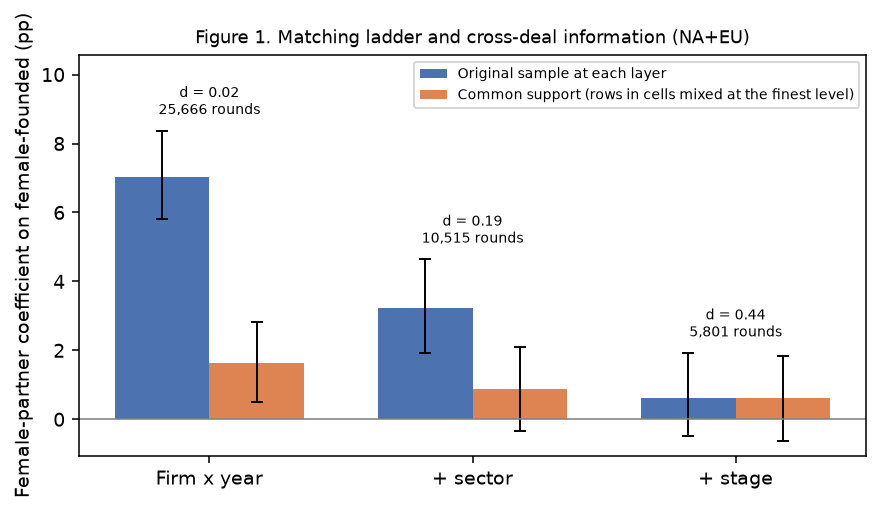

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
names = ["Firm x year", "+ sector", "+ stage"]; keys61 = ["L0_invyear", "L1_pluscat", "L2_plusstage"]
vo = [e61["B_original_ladder"][k]["coef_pp"] for k in keys61]; lo_o = [e61["B_original_ladder"][k]["ci95_pp"][0] for k in keys61]; hi_o = [e61["B_original_ladder"][k]["ci95_pp"][1] for k in keys61]
vc = [e61["C_common_support_ladder"][k]["coef_pp"] for k in keys61]; lo_c = [e61["C_common_support_ladder"][k]["ci95_pp"][0] for k in keys61]; hi_c = [e61["C_common_support_ladder"][k]["ci95_pp"][1] for k in keys61]
x = np.arange(3)
ax.bar(x - 0.18, vo, 0.36, color="#4C72B0", label="Original sample at each layer")
ax.bar(x + 0.18, vc, 0.36, color="#DD8452", label="Common support (rows in cells mixed at the finest level)")
ax.errorbar(x - 0.18, vo, yerr=[np.array(vo) - lo_o, np.array(hi_o) - vo], fmt="none", ecolor="black", capsize=3, lw=1)
ax.errorbar(x + 0.18, vc, yerr=[np.array(vc) - lo_c, np.array(hi_c) - vc], fmt="none", ecolor="black", capsize=3, lw=1)
for k_, xi in zip(keys61, x):
    dg = e61["A_diagnostics_by_cell"][k_]
    ax.text(xi, max(hi_o[xi], hi_c[xi]) + 0.35, f"d = {dg['d_share_sxx_single_round']:.2f}\n{dg['n_unique_rounds_mixed']:,} rounds", ha="center", va="bottom", fontsize=7)
ax.axhline(0, color="grey", lw=0.8); ax.set_xticks(x, names); ax.set_ylabel("Female-partner coefficient on female-founded (pp)")
ax.set_ylim(top=max(hi_o + hi_c) + 2.2); ax.set_title("Figure 1. Matching ladder and cross-deal information (NA+EU)", fontsize=9); ax.legend(fontsize=7, loc="upper right")
fig.tight_layout(); fig.savefig(os.path.join(OUT_F, "figure1_ladder.png"))

# Figure 2: rank change — mean percentile by gender, raw vs adjusted, at three benchmark levels (sample end) and at the fixed horizons


## Figure 2 — Benchmark adjustment and partners' mean percentile ranks, by gender


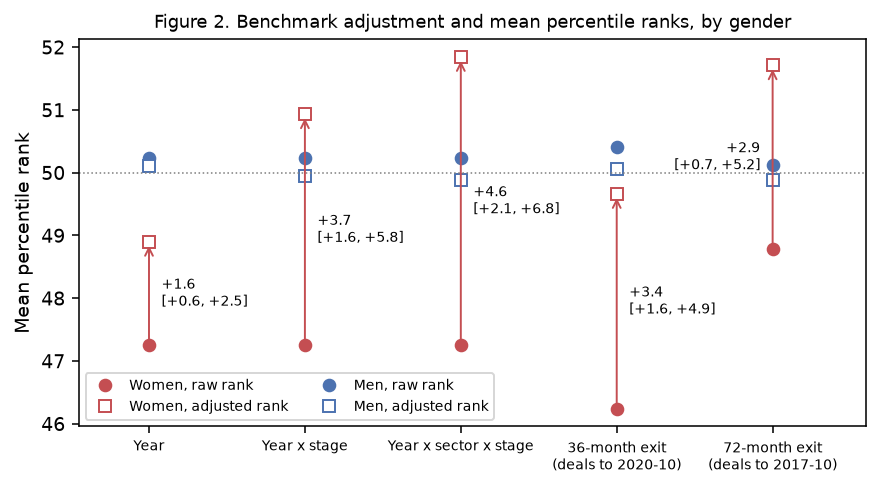

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
levels = [("Year", e62["B_benchmark_levels_sample_end"]["year"]), ("Year x stage", e62["B_benchmark_levels_sample_end"]["year_stage"]), ("Year x sector x stage", e62["A_accounting_sample_end"]),
          ("36-month exit\n(deals to 2020-10)", e62["C_fixed_horizon"]["exit3_deals_to_2020_10"]["year_sector_stage"]), ("72-month exit\n(deals to 2017-10)", e62["C_fixed_horizon"]["exit6_deals_to_2017_10"]["year_sector_stage"])]
x = np.arange(len(levels))
fr = [v["female_raw_pct"]["coef"] for _, v in levels]; fa = [v["female_adj_pct"]["coef"] for _, v in levels]; mr = [v["male_raw_pct"]["coef"] for _, v in levels]; ma = [v["male_adj_pct"]["coef"] for _, v in levels]
ax.plot(x, fr, "o", color="#C44E52", label="Women, raw rank"); ax.plot(x, fa, "s", color="#C44E52", mfc="white", label="Women, adjusted rank")
ax.plot(x, mr, "o", color="#4C72B0", label="Men, raw rank"); ax.plot(x, ma, "s", color="#4C72B0", mfc="white", label="Men, adjusted rank")
for xi in x: ax.annotate("", xy=(xi, fa[xi]), xytext=(xi, fr[xi]), arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1))
for xi, (_, v) in enumerate(levels): ax.text(xi + (-0.08 if xi == len(levels) - 1 else 0.08), (fr[xi] + fa[xi]) / 2, f"{v['female_shift']['coef']:+.1f}\n[{v['female_shift']['ci95'][0]:+.1f}, {v['female_shift']['ci95'][1]:+.1f}]", fontsize=7, va="center", ha=("right" if xi == len(levels) - 1 else "left"))
ax.set_xticks(x, [l for l, _ in levels], fontsize=7); ax.set_xlim(-0.45, len(levels) - 0.4); ax.set_ylabel("Mean percentile rank"); ax.axhline(50, color="grey", lw=0.8, ls=":")
ax.set_title("Figure 2. Benchmark adjustment and mean percentile ranks, by gender", fontsize=9); ax.legend(fontsize=7, ncol=2, loc="lower left")
fig.tight_layout(); fig.savefig(os.path.join(OUT_F, "figure2_rank_change.png"))

# Figure 3: horizon dependence on one sample (deals through 2017-10), with differences from the same draws


## Figure 3 — The within-partner differential across exit horizons on one sample


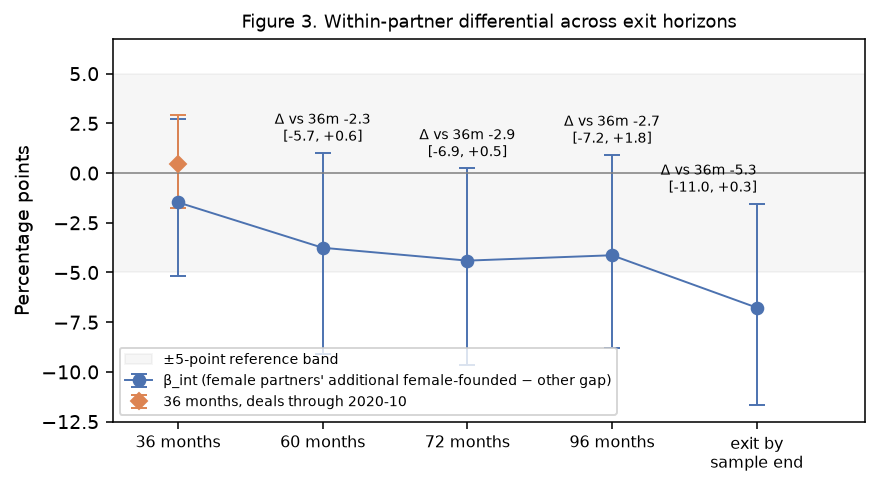

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
hz = [("36", "exit3"), ("60", "exit5"), ("72", "exit6"), ("96", "exit8"), ("eventual", "exit_ever")]
x = np.arange(len(hz)); vals = [e57["A_2017"][k]["ffp"]["coef"] * 100 for _, k in hz]; lo = [e57["A_2017"][k]["ffp"]["ci95"][0] * 100 for _, k in hz]; hi = [e57["A_2017"][k]["ffp"]["ci95"][1] * 100 for _, k in hz]
ax.errorbar(x, vals, yerr=[np.array(vals) - lo, np.array(hi) - vals], fmt="o-", color="#4C72B0", capsize=4, lw=1, label="β_int (female partners' additional female-founded − other gap)")
v20 = e57["B_2020"]["exit3"]["ffp"]; ax.errorbar([0], [v20["coef"] * 100], yerr=[[v20["coef"] * 100 - v20["ci95"][0] * 100], [v20["ci95"][1] * 100 - v20["coef"] * 100]], fmt="D", color="#DD8452", capsize=4, lw=1, label="36 months, deals through 2020-10")
ax.axhline(0, color="grey", lw=0.8); ax.axhspan(-5, 5, color="grey", alpha=0.07, label="±5-point reference band")
_H = e57["A_horizon_differences_same_draws"]
for xi, (_, k) in enumerate(hz[1:], start=1):
    dk = _H[f"{k}_minus_exit3"]; ax.text(xi, hi[xi] + 0.6, f"Δ vs 36m {dk['coef']*100:+.1f}\n[{dk['ci95'][0]*100:+.1f}, {dk['ci95'][1]*100:+.1f}]", ha=("right" if xi == len(hz) - 1 else "center"), fontsize=7)
ax.set_xticks(x, [f"{h} months" if h != "eventual" else "exit by\nsample end" for h, _ in hz], fontsize=8); ax.set_ylabel("Percentage points"); ax.set_ylim(top=max(hi) + 4); ax.set_xlim(-0.45, len(hz) - 0.25)
ax.set_title("Figure 3. Within-partner differential across exit horizons", fontsize=9); ax.legend(fontsize=7, loc="lower left")
fig.tight_layout(); fig.savefig(os.path.join(OUT_F, "figure3_horizon.png"))

# Supplementary figures (Internet Appendix): event study (former Figure 2) and the financing-ladder channel (former Figure 3)


## Appendix Figure A1 — Female-partner arrivals and new-deal composition


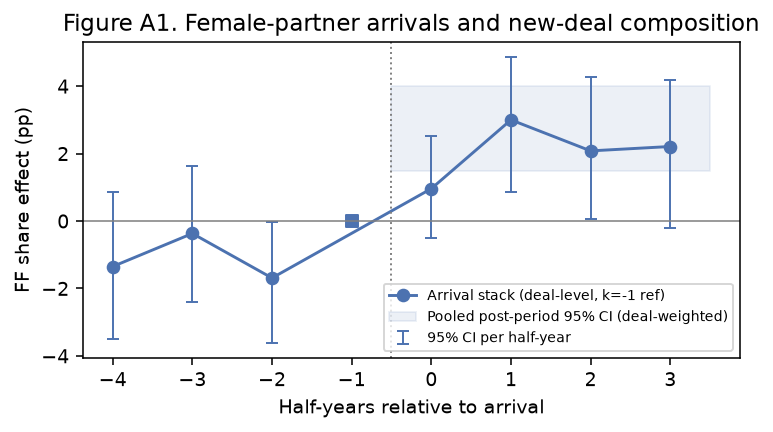

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
pj_ = e11["path_join"]
ks = sorted(int(k) for k in pj_)
ys = [pj_[str(k)] for k in ks]
ax.plot([k for k in ks], ys, "o-", color="#4C72B0", label="Arrival stack (deal-level, k=-1 ref)")
pci = e11.get("path_join_ci", {})
if pci:
    ax.errorbar([k for k in ks if str(k) in pci], [pj_[str(k)] for k in ks if str(k) in pci], yerr=[[pj_[str(k)] - pci[str(k)][0] for k in ks if str(k) in pci], [pci[str(k)][1] - pj_[str(k)] for k in ks if str(k) in pci]], fmt="none", ecolor="#4C72B0", capsize=3, lw=1, label="95% CI per half-year")
ax.scatter([-1], [0], color="#4C72B0", marker="s")
ax.axvline(-0.5, color="grey", ls=":", lw=1)
ax.axhline(0, color="grey", lw=0.8)
ax.fill_between([-0.5, 3.5], e11["join"][1][0] * 100, e11["join"][1][1] * 100, color="#4C72B0", alpha=0.10, label="Pooled post-period 95% CI (deal-weighted)")
ax.set_xlabel("Half-years relative to arrival")
ax.set_ylabel("FF share effect (pp)")
ax.set_title("Figure A1. Female-partner arrivals and new-deal composition")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(OUT_F, "figureA1_eventstudy.png"))


## Appendix Figure A2 — Female-partner share by stage


figures: figure1-3 + IA.1-2 saved


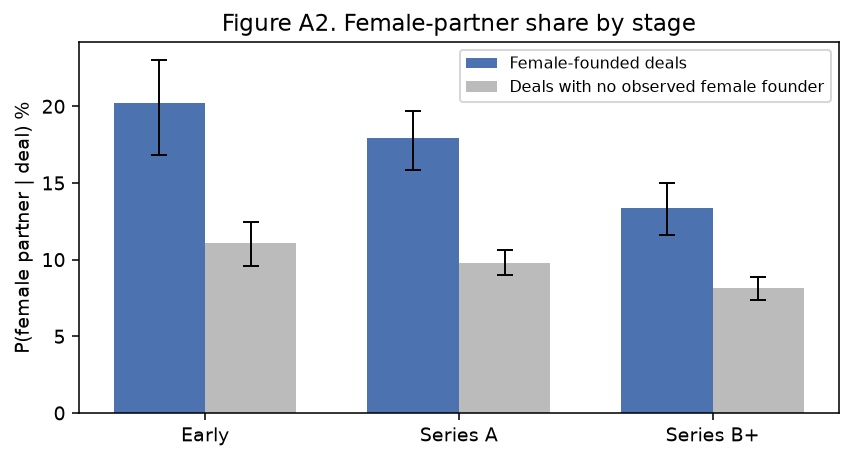

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
x = np.arange(3)
cf = [c for c in e6["p_fp_given_ff"][1]]
ax.bar(x - 0.18, pf, 0.36, label="Female-founded deals", color="#4C72B0")
ax.bar(x + 0.18, pm, 0.36, label="Deals with no observed female founder", color="#BBBBBB")
ax.errorbar(x - 0.18, pf, yerr=[[pf[i] - cf[i][0] * 100 for i in range(3)],
                                [cf[i][1] * 100 - pf[i] for i in range(3)]],
            fmt="none", ecolor="black", capsize=4, lw=1)
cm = [c for c in e6["p_fp_given_mf"][1]]
ax.errorbar(x + 0.18, pm, yerr=[[pm[i] - cm[i][0] * 100 for i in range(3)], [cm[i][1] * 100 - pm[i] for i in range(3)]], fmt="none", ecolor="black", capsize=4, lw=1)
ax.set_xticks(x, ["Early", "Series A", "Series B+"])
ax.set_ylabel("P(female partner | deal) %")
ax.set_title("Figure A2. Female-partner share by stage")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_F, "figureA2_channel.png"))
print("figures: figure1-3 + IA.1-2 saved")


## Consistency check — regenerated figures versus the paper's figure files
SHA-256 of each PNG just written to `../figures/` against the file attached to the manuscript.


In [ ]:
import hashlib, os
def sha(p): return hashlib.sha256(open(p, "rb").read()).hexdigest()
fails = 0
for n in ["figure1_ladder", "figure2_rank_change", "figure3_horizon", "figureA1_eventstudy", "figureA2_channel"]:
    a, b = sha(os.path.join(OUT_F, n + ".png")), sha(os.path.join("../paper_exhibits/figures", n + ".png"))
    ok = a == b; fails += (not ok); print(f"{n:<18} {'IDENTICAL' if ok else 'DIFFERS'}  sha256 {a[:16]}")
assert fails == 0, f"{fails} figure(s) differ from the paper"
print("\nAll 5 figures are byte-identical to the paper's figure files.")


figure1_ladder     IDENTICAL  sha256 e4bba3236b3d63c1
figure2_rank_change IDENTICAL  sha256 f9da2fe7905f9d40
figure3_horizon    IDENTICAL  sha256 440b76cfa8bd800c
figureA1_eventstudy IDENTICAL  sha256 497265932b09328f
figureA2_channel   IDENTICAL  sha256 29ad73421e8ff2c6

All 5 figures are byte-identical to the paper's figure files.
